In [1]:
import numpy as np 
import rebound
import os
import matplotlib.pyplot as plt
import dill
import pandas as pd

In [2]:
tess_offset =  2457000

# Definitions

In [3]:
def mean_anomaly(t, omega, e, Tc, P):
    """
    Calculate mean anomaly M at time t, given:
    - omega: argument of periastron (radians)
    - e: eccentricity
    - Tc: time of inferior conjunction (transit)
    - P: orbital period
    
    Converts Tc to periastron passage time tau using the formula:
    2*pi*(Tc - tau)/P = E0 - e*sin(E0)
    with E0 = 2 * arctan(sqrt((1-e)/(1+e)) * tan(pi/2 - omega/2))
    
    Returns mean anomaly M in radians [0, 2pi).
    """
    # Compute E0 from e and omega
    E0 = 2 * np.arctan( np.sqrt((1 - e) / (1 + e)) * np.tan(np.pi/4 - omega/2) )
    E0 = E0 % (2 * np.pi)

    # Compute time of periastron passage tau
    tau = Tc - (P / (2 * np.pi)) * (E0 - e * np.sin(E0))
    # print(tau[0], omega[0], e[0], Tc[0], P[0] )
    # print(f'tau: {tau[0]}') 
    # print(f'omega: {omega[0]}')
    # print(f'e: {e[0]}')
    # print(f'Tc: {Tc[0]}')
    # print(f'P: {P[0]}')

    # Compute mean anomaly at time t
    M = (2 * np.pi / P) * (t - tau)
    M = M % (2 * np.pi)

    return M


# Data

In [4]:
### get the posterior data
# file_name = '1339_jnkep_fit_1339-2000burn-2000step-emax0.5.pkl'
file_name = '1339_jnkep_nburn-1000_nsteps-1000_hessian_tree-11_accept-95_emax-0.5.pkl'

working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")

file_path = os.path.join(data_dir, file_name)

In [5]:
with open(file_name, "rb") as f:
    mcmc = dill.load(f)
mcmc.print_summary()
print(mcmc)

posterior = mcmc.get_samples(group_by_chain=True)  # shape: (num_chains, num_samples, ...)
print({k: v.shape for k, v in posterior.items()})


                      mean       std    median      5.0%     95.0%     n_eff     r_hat
 ecosw_scaled[0]      0.33      0.07      0.32      0.22      0.43    157.16      1.03
 ecosw_scaled[1]      0.35      0.06      0.34      0.25      0.44    157.72      1.03
 esinw_scaled[0]      0.36      0.09      0.36      0.22      0.51    151.05      1.05
 esinw_scaled[1]      0.38      0.08      0.38      0.26      0.51    150.82      1.05
period_scaled[0]      0.50      0.00      0.50      0.50      0.50    214.86      1.03
period_scaled[1]      0.50      0.00      0.50      0.50      0.50    350.97      1.03
 pmass_scaled[0]      0.02      0.00      0.02      0.01      0.02    253.05      1.03
 pmass_scaled[1]      0.01      0.00      0.01      0.01      0.01    195.19      1.03
   tic_scaled[0]      0.48      0.00      0.48      0.48      0.49    181.14      1.04
   tic_scaled[1]      0.51      0.01      0.51      0.50      0.53    234.54      1.05

Number of divergences: 30
{'ecc': (8, 100

In [6]:
good_chain_idxs = [0,1,2,3,4,5,6,7]

samples_filtered = {
    k: v[good_chain_idxs, ...] for k, v in posterior.items()
}
# print(samples_filtered)
samples = {
    k: v.reshape(-1, *v.shape[2:]) for k, v in samples_filtered.items()
}

# Shape of samples
print({k: v.shape for k, v in samples.items()})


{'ecc': (8000, 2), 'ecosw': (8000, 2), 'ecosw_scaled': (8000, 2), 'ediff': (8000,), 'esinw': (8000, 2), 'esinw_scaled': (8000, 2), 'period': (8000, 2), 'period_scaled': (8000, 2), 'pmass': (8000, 2), 'pmass_scaled': (8000, 2), 'tcmodel': (8000, 39), 'tic': (8000, 2), 'tic_scaled': (8000, 2)}


In [7]:
### conversions
solar_mass_2_kg = 1.989e30 # [kg per solar mass]
d_2_s = 86400 # [seconds per day]

### system constants 
m_star = 0.81  # [solar mass]

from astropy import units as u
from astropy import constants as c
G_const_si = c.G
G_const = c.G.to(u.AU**3 / u.M_sun / u.day**2).value


### posterior samples 
ecosw_c = samples["ecosw"][:, 0]
esinw_c = samples["esinw"][:, 0]
# e_c = samples["ecc"][:,0]
P_c = samples["period"][:,0] # [days]
Tc_c = samples["tic"][:,0] # [days]
m_c = samples["pmass"][:,0] # [solar mass]

ecosw_d = samples["ecosw"][:, 1]
esinw_d = samples["esinw"][:, 1]
# e_d = samples["ecc"][:,1]
P_d = samples["period"][:,1] # [days]
Tc_d = samples["tic"][:,1] # [days]
m_d = samples["pmass"][:,1] # [solar mass]  

### calculated params
a_c = np.array(((G_const*m_star*P_c**2)/(4*np.pi**2))**(1.0/3.)) # [AU]
a_d = np.array(((G_const*m_star*P_d**2)/(4*np.pi**2))**(1./3.)) # [AU]

e_c = np.sqrt(ecosw_c**2 + esinw_c**2)
e_d = np.sqrt(ecosw_d**2 + esinw_d**2)
omega_c = np.arctan2(esinw_c, ecosw_c) # [rad]
omega_d = np.arctan2(esinw_d, ecosw_d) # [rad]

# times = np.array([1980.] * len(omega_c))
times = Tc_d
ref_time = 0.0 # set to simulation start time

Mean_anomaly_c = mean_anomaly(ref_time, omega_c, e_c, Tc_c, P_c)
Mean_anomaly_d = mean_anomaly(ref_time, omega_d, e_d, Tc_d, P_d)

### keep Omega constant
value_Omega_c = 0  # [deg]
Omega_c = np.full_like(omega_c, np.radians(value_Omega_c))
value_Omega_d = 0 # [deg]
Omega_d = np.full_like(omega_d, np.radians(value_Omega_d))

pomega_c = omega_c + Omega_c
pomega_d = omega_d + Omega_d
lambda_c = omega_c + Omega_c + Mean_anomaly_c
lambda_d = omega_d + Omega_d + Mean_anomaly_d

# Set fixed inclination (e.g. edge-on)
inc_c = [np.pi / 2] * len(a_c)
inc_d = [np.pi / 2] * len(a_d)

print(a_c)
print(m_c)
print(np.array(Omega_c))

[0.17053477 0.17053477 0.17053476 ... 0.17053413 0.17053482 0.1705335 ]
[1.32594778e-05 1.32760388e-05 1.31379475e-05 ... 1.42283043e-05
 1.88686045e-05 1.86341822e-05]
[0. 0. 0. ... 0. 0. 0.]


In [8]:
r_apo_c = a_c * (1 + e_c)
r_peri_d = a_d * (1 - e_d)
initially_crossed=[]
for i in range(len(r_apo_c)):
    r_apo = r_apo_c[i]
    r_peri = r_peri_d[i]
    if r_peri < r_apo:
        initially_crossed.append(i)

print(f'Systems where initial posterior state has r_peri_d < r_apo_c: {len(initially_crossed)}')

Systems where initial posterior state has r_peri_d < r_apo_c: 7322


In [9]:
# Set parameters (fixed values from literature) Polanski, orell-miquel
from astropy.constants import M_jup, M_sun
mass_b = 0.0302 * (M_jup / M_sun)
a_b = 0.079
e_b = 0.0
omega_b = np.radians(90.)
Omega_b = 0.0 # assume 0
inc_b = np.pi / 2
Tc_b = 2458715.35572 - tess_offset
P_b = 8.8803232



mass_e = 0.3590 * (M_jup / M_sun)  # MJup to Msun
a_e = 0.400
e_e = 0.0
omega_e = np.radians(230.0)
Omega_e = 0.0  # Assume 0 for simplicity
inc_e = np.pi / 2  # edge-on
Tc_e = 2459044.0 - tess_offset
P_e = 101.5

# Reference time = same as for other planets
# t_ref = times[i]  # or pick a fixed time like 2459000

M_e = mean_anomaly(np.median(Tc_d), omega_e, e_e, Tc_e, P_e)
M_b = mean_anomaly(np.median(Tc_d), omega_b, e_b, Tc_b, P_b)

pomega_b = omega_b + Omega_b
pomega_e = omega_e + Omega_e
lambda_b = omega_b + Omega_b + M_b
lambda_e = omega_e + Omega_e + M_e

# Hamiltonian 

In [10]:
def Lambda_k(mk,ak,mu):
    Lambda_k = mk*np.sqrt(mu*ak)
    return Lambda_k

def Ck(Lambda_k, ek):
    Ck = Lambda_k*(1 - np.sqrt(1-ek**2))
    return Ck

def Gamma_(p,Lambda1, Lambda2):
    Gamma = ((p+1)/p)*Lambda1 + Lambda2
    return Gamma

def G_(Lambda1, Lambda2, C1, C2):
    G = Lambda1 + Lambda2 - C1 - C2
    return G

def theta_res_(p, lambda1, lambda2):
    theta_res = (p+1)*lambda2 - p*lambda1
    return theta_res

def xk(Ck, pomega_k, theta_res):
    xk = np.sqrt(Ck) * np.exp(1j * (pomega_k - theta_res))
    return xk

#--- Laplace coefficient b_s^k(alpha) integral ---
from scipy.integrate import quad
def b(s, k, alpha):
    alpha = float(alpha)
    # Integrand for Laplace coefficient (eq. A10)
    def integrand(phi):
        denom = (1 - 2*alpha*np.cos(phi) + alpha**2)**s
        return np.cos(k*phi) / denom
    integral, _ = quad(integrand, -np.pi, np.pi, limit=200)
    # For k=0 factor 1/2 applies inside the integral by definition
    if k == 0:
        return integral / (2 * np.pi)
    else:
        return integral / np.pi


def script_R1_(alpha, p):
    factor = alpha / 4
    term1 = 3*b(3/2,p,alpha)
    term2 = 2*alpha*b(3/2, p+1, alpha)
    term3 = b(3/2, p+2, alpha)
    script_R1 = -factor*(term1 - term2 - term3)
    # script_R1 = -(alpha/4) * (3*b(3/2,p,alpha) - 2*alpha*b(3/2,p+1,alpha) - b(3/2,p+2,alpha))
    return script_R1

def script_R2_(alpha, p):
    factor = alpha /4
    term1 = 3*b(3/2, p-1, alpha)
    term2 = 2*alpha*b(3/2, p, alpha)
    term3 = b(3/2,p+1,alpha)
    term4 = (1/2)*b(1/2,p,alpha)
    script_R2 = factor*(term1 - term2 - term3) + term4
    # script_R2 = (alpha/4) * (3*b(3/2,p-1,alpha) - 2*alpha*b(3/2,p,alpha) - b(3/2,p+1,alpha)) + (1/2)*b(1/2,p,alpha)
    return script_R2

def R1_(gamma, mu, m2, Lambda1, Lambda2, script_R1):
    term1 = gamma / (1+gamma)
    term2 = (mu**2 * m2**3)/(Lambda2**2)
    term3 = (1/2)*np.sqrt(2/Lambda1)
    R1 = -term1*term2*term3*script_R1
    # R1 = -(gamma/(1+gamma))*((mu**2*m2**3)/(Lambda2**2))*(1/2)*np.sqrt(2/Lambda1)*script_R1
    return R1

def R2_(gamma, mu, m2, Lambda2, script_R2):
    term1 = gamma / (1+gamma)
    term2 = (mu**2 * m2**3) / (Lambda2**2)
    term3 = (1/2)*np.sqrt(2/Lambda2)
    R2 = -term1*term2*term3*script_R2
    # R2 = -(gamma/(1+gamma)) * ((mu**2 * m2**3)/(Lambda2**2)) * (1/2)*np.sqrt(2/Lambda2)*script_R2
    return R2

def I1_(R1, R2, C1, C2, Delta_pomega):
    factor = 1/(R1**2 + R2**2)
    term1 = R1**2 * C1
    term2 = R2**2 * C2
    term3 = 2*R1*R2* np.sqrt(C1*C2)*np.cos(Delta_pomega)
    I1 = factor* (term1 + term2 + term3)
    # I1 = (1/(R1**2 + R2**2))*(R1**2*C1 + R2**2*C2 + 2*R1*R2*np.sqrt(C1*C2)*np.cos(Delta_pomega))
    return I1

def I2_(R1, R2, C1, C2, Delta_pomega):
    factor = 1/(R1**2 + R2**2)
    term1 = R2**2 * C1
    term2 = R1**2 * C2
    term3 = 2*R1*R2* np.sqrt(C1*C2) * np.cos(Delta_pomega)
    I2 = factor*(term1 + term2 - term3)
    # I2 = (1/(R1**2 + R2**2))*(R2**2*C1 + R1**2*C2 - 2*R1*R2*np.sqrt(C1*C2)*np.cos(Delta_pomega))
    return I2

def K2_(P2, Lambda2, p, gamma, alpha):
    n2 = (2*np.pi)/P2
    K2 = -((3*n2)/(2*Lambda2)) * (p+1)**2 * ((gamma+alpha)/alpha)
    return K2

def Delta_G_(Gamma, p, gamma, alpha_0,G):
    Delta_G = (Gamma/(p+1)) * ((p*gamma + (p+1)*alpha_0)/(gamma+alpha_0)) - G
    return Delta_G


def y1_(x1, x2, R1, R2):
    term1 = (R1/(np.sqrt(R1**2 + R2**2))) * x1
    term2 = (R2/(np.sqrt(R1**2 + R2**2))) * x2
    y1 = term1 + term2
    return y1

def y2_(x1, x2, R1, R2):
    term1 = (R2/(np.sqrt(R1**2 + R2**2))) * x1
    term2 = (R1/(np.sqrt(R1**2 + R2**2))) * x2
    y1 = term1 - term2
    return y1

def hamiltonian(K2, I1, I2, Delta_G, eps, R1, R2, theta1):
    H = (K2)*(I1 + I2 - Delta_G)**2 + 2*eps*np.sqrt(R1**2 + R2**2)*np.sqrt(I1)*np.cos(theta1)
    return H


## defining Y1 and Y2

In [11]:
# def Y1_(e_tilda_1, e_tilda_2, pomega_1, pomega_2, gamma, theta_res):
#     numerator = (e_tilda_1*np.exp(1j * pomega_1)) - (1.22*e_tilda_2*np.exp(1j * pomega_2))
#     denominator = np.sqrt(1 + 1.31*gamma)
#     Y1 = (numerator/denominator) * np.exp(-1j * theta_res)
#     return Y1

# def Y2_(e_tilda_1, e_tilda_2, pomega_1, pomega_2, gamma, theta_res):
#     numerator = (1.07*gamma*e_tilda_1*np.exp(1j * pomega_1)) + (e_tilda_2*np.exp(1j * pomega_2))
#     denominator = np.sqrt(1 + 1.31*gamma)
#     Y2 = (numerator/denominator) * np.exp(-1j * theta_res)
#     return Y2

def Y1_(Lambda_c, y1):
    term1 = np.sqrt(2/Lambda_c)
    Y1 = term1 * y1
    return Y1


def Y2_(Lambda_d, y2):
    term1 = np.sqrt(2/Lambda_d)
    Y2 = term1 * y2
    return Y2

## make posterior distribution plot for Y1

In [12]:
### conversions
solar_mass_2_kg = 1.989e30 # [kg per solar mass]
d_2_s = 86400 # [seconds per day]

### system constants 
m_star = 0.81  # [solar mass]

from astropy import units as u
from astropy import constants as c
G_const_si = c.G
G_const = c.G.to(u.AU**3 / u.M_sun / u.day**2).value


### posterior samples 
ecosw_c = samples["ecosw"][:, 0]
esinw_c = samples["esinw"][:, 0]
e_c = samples["ecc"][:,0]
P_c = samples["period"][:,0] # [days]
Tc_c = samples["tic"][:,0] # [days]
m_c = samples["pmass"][:,0] # [solar mass]

ecosw_d = samples["ecosw"][:, 1]
esinw_d = samples["esinw"][:, 1]
e_d = samples["ecc"][:,1]
P_d = samples["period"][:,1] # [days]
Tc_d = samples["tic"][:,1] # [days]
m_d = samples["pmass"][:,1] # [solar mass]  

### calculated params
a_c = np.array(((G_const*m_star*P_c**2)/(4*np.pi**2))**(1.0/3)) # [AU]
a_d = np.array(((G_const*m_star*P_d**2)/(4*np.pi**2))**(1/3)) # [AU]


omega_c = np.arctan2(esinw_c, ecosw_c) # [rad]
omega_d = np.arctan2(esinw_d, ecosw_d) # [rad]

# times = np.array([1980.] * len(omega_b))
times = Tc_d

Mean_anomaly_c = mean_anomaly(times, omega_c, e_c, Tc_c, P_c)
Mean_anomaly_d = mean_anomaly(times, omega_d, e_d, Tc_d, P_d)
e_tilda_c = np.sqrt(2*(1 - np.sqrt(1 - e_c**2)))
e_tilda_d = np.sqrt(2*(1 - np.sqrt(1 - e_d**2)))

### keep Omega constant
value_Omega_c = 0  # [deg]
Omega_c = [np.radians(value_Omega_c)] * len(omega_c)  # [rad]
value_Omega_d = 0 # [deg]
Omega_d = [np.radians(value_Omega_d)] * len(omega_d)  # [rad]

pomega_c = omega_c + Omega_c
pomega_d = omega_d + Omega_d
lambda_c = omega_c + Omega_c + Mean_anomaly_c
lambda_d = omega_d + Omega_d + Mean_anomaly_d
p = np.array([3] * len(lambda_c))
theta_res = theta_res_(p, lambda_c, lambda_d)

# print(a_b)
# print(a_c)
print(e_tilda_c)
print(e_tilda_d)
print(e_c)
print(e_d)
print(pomega_c)
print(pomega_d)
print(theta_res)

[0.01288174 0.01374579 0.01253942 ... 0.31698292 0.19040903 0.28851017]
[0.01226062 0.01302439 0.01206954 ... 0.27251738 0.16214393 0.24662554]
[0.0128797  0.01374458 0.0125366  ... 0.31297633 0.18954419 0.28549263]
[0.01225882 0.01302479 0.0120679  ... 0.26997554 0.16160995 0.24474324]
[ 2.18906832  2.43125892  2.61778998 ... -2.3261447  -2.69725275
 -2.15303707]
[ 2.21169901  2.44046879  2.61558414 ... -2.32986641 -2.69937921
 -2.15222979]
[15.17465  15.177904 15.179148 ...  9.069724  9.018856  9.003483]


In [13]:
eps = (m_c+m_d)/m_star
mu = np.array([G_const*m_star] * len(omega_c))
gamma = m_c/m_d 
alpha = a_c/a_d 
alpha_0 = (p/(p+1))**(2/3)
Delta_pomega = pomega_d - pomega_c # ??

print(alpha)
print(alpha_0)
print(Delta_pomega)

[0.82200485 0.82200557 0.8220052  ... 0.82199675 0.8219998  0.8219767 ]
[0.82548181 0.82548181 0.82548181 ... 0.82548181 0.82548181 0.82548181]
[ 0.02263069  0.00920987 -0.00220585 ... -0.00372171 -0.00212646
  0.00080729]


In [14]:


theta_res = theta_res_(p, lambda_c, lambda_d)

Lambda_c = Lambda_k(m_c,a_c,mu)
Lambda_d = Lambda_k(m_d,a_d,mu)

C_c = Ck(Lambda_c, e_c)
C_d = Ck(Lambda_d, e_d)

x1 = xk(C_c, pomega_c, theta_res)
x2 = xk(C_d, pomega_d, theta_res)

script_R1 = np.array([script_R1_(a, p_val) for a, p_val in zip(alpha, p)])
script_R2 = np.array([script_R2_(a, p_val) for a, p_val in zip(alpha, p)])
# script_R1 = script_R1_(alpha, p)
# script_R2 = script_R2_(alpha, p)

R1 = R1_(gamma, mu, m_d, Lambda_c, Lambda_d, script_R1)
R2 = R2_(gamma, mu, m_d, Lambda_d, script_R2)



y1 = y1_(x1, x2, R1, R2)
y2 = y2_(x1, x2, R1, R2)

## Plotting posterior for Y1

In [15]:
# Y1 = Y1_(e_tilda_c, e_tilda_d, pomega_c, pomega_d, gamma, theta_res)

Y1 = Y1_(Lambda_c, y1)

print(np.median(Y1))

(-2.5611367e-05+0.0007951737j)


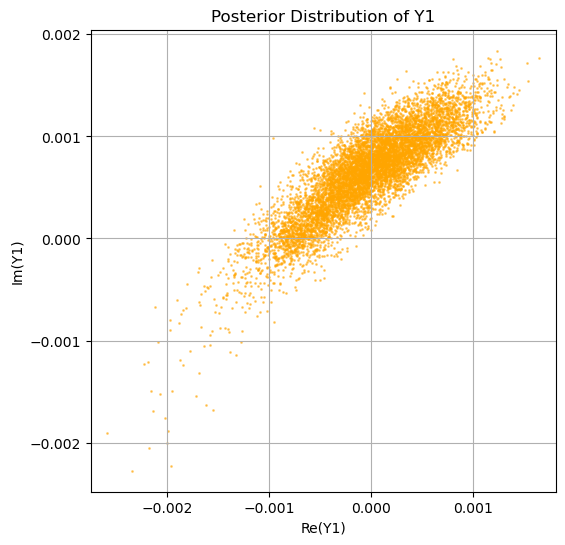

In [16]:
# Extract real and imaginary parts
Y1_real = np.real(Y1)
Y1_imag = np.imag(Y1)

plt.figure(figsize=(6, 6))
plt.scatter(Y1_real, Y1_imag, s=1, alpha=0.5,color='orange')  # Adjust s for point size, alpha for transparency
plt.xlabel("Re(Y1)")
plt.ylabel("Im(Y1)")
plt.title("Posterior Distribution of Y1")
plt.grid(True)
plt.axis('equal')  # Optional: ensures square aspect ratio
plt.show()

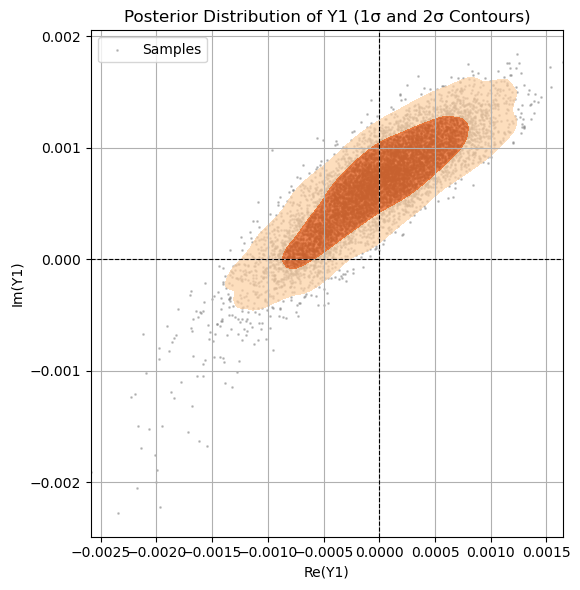

In [17]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import numpy as np

def compute_kde_contour_levels(x, y, gridsize=100):
    data = np.vstack([x, y])
    kde = gaussian_kde(data)
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    X, Y = np.mgrid[x_min:x_max:gridsize*1j, y_min:y_max:gridsize*1j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kde(positions).T, X.shape)
    return X, Y, Z

def get_sigma_contour_levels(Z):
    Z_flat = Z.flatten()
    Z_sorted = np.sort(Z_flat)[::-1]
    cumsum = np.cumsum(Z_sorted)
    cumsum /= cumsum[-1]  # Normalize to total probability 1
    levels = []
    for sigma in [0.683, 0.954]:
        idx = np.searchsorted(cumsum, sigma)
        levels.append(Z_sorted[idx])
    return sorted(levels)

# Extract real and imaginary parts of Y1
Y1_real = np.real(Y1)
Y1_imag = np.imag(Y1)

# Compute KDE and contour levels
X_1, Y_1, Z_1 = compute_kde_contour_levels(Y1_real, Y1_imag)
levels_1 = get_sigma_contour_levels(Z_1)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(Y1_real, Y1_imag, s=1, alpha=0.4, color='grey',label='Samples')

contour = ax.contourf(X_1, Y_1, Z_1, levels=levels_1 + [Z_1.max()], colors=["#fdd0a2", "#e6550d"], alpha=0.7)

# Add dashed lines at x=0 and y=0
ax.axhline(0, color='black', linestyle='--', lw=0.8)
ax.axvline(0, color='black', linestyle='--', lw=0.8)

# Plot formatting
ax.set_xlabel("Re(Y1)")
ax.set_ylabel("Im(Y1)")
ax.set_title("Posterior Distribution of Y1 (1σ and 2σ Contours)")
ax.grid(True)
ax.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()


## Posterior for Y2

In [18]:
# Y2 = Y2_(e_tilda_c, e_tilda_d, pomega_c, pomega_d, gamma, theta_res)
Y2 = Y2_(Lambda_d, y2)
print(Y2)

[-0.01873309+8.1776343e-03j -0.02140713+3.8330304e-03j
 -0.02004279-8.5602238e-05j ... -0.18826889-4.4345856e-01j
 -0.17402835-1.9788308e-01j -0.06923989-4.2719787e-01j]


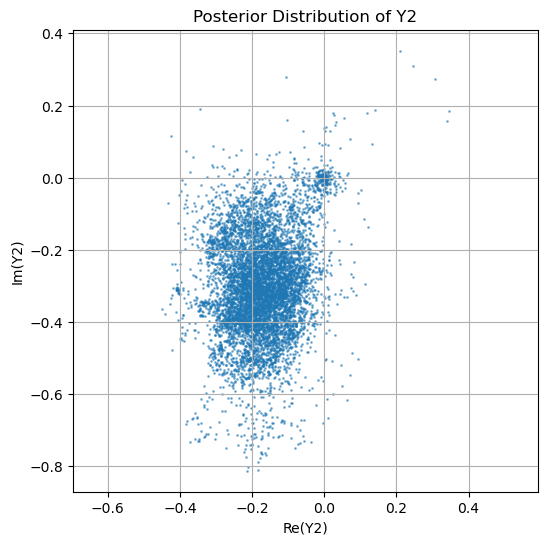

In [19]:
# Extract real and imaginary parts
Y2_real = np.real(Y2)
Y2_imag = np.imag(Y2)

plt.figure(figsize=(6, 6))
plt.scatter(Y2_real, Y2_imag, s=1, alpha=0.5)  # Adjust s for point size, alpha for transparency
plt.xlabel("Re(Y2)")
plt.ylabel("Im(Y2)")
plt.title("Posterior Distribution of Y2")
plt.grid(True)
plt.axis('equal')  # Optional: ensures square aspect ratio
plt.show()

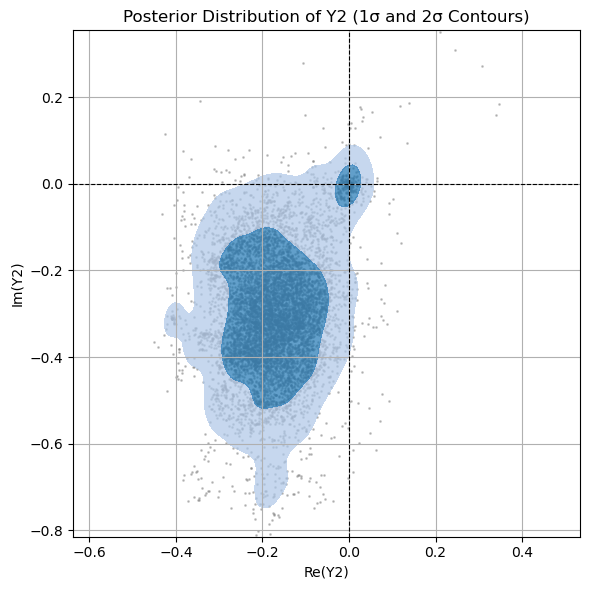

In [20]:
# Extract real and imaginary parts of Y1
Y2_real = np.real(Y2)
Y2_imag = np.imag(Y2)

# Compute KDE and contour levels
X_2, Y_2, Z_2 = compute_kde_contour_levels(Y2_real, Y2_imag)
levels_2 = get_sigma_contour_levels(Z_2)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(Y2_real, Y2_imag, s=1, alpha=0.4, color='grey',label='Samples')

contour = ax.contourf(X_2, Y_2, Z_2, levels=levels_2 + [Z_2.max()], colors=["#aec7e8", "#1f77b4"], alpha=0.7)

# Add dashed lines at x=0 and y=0
ax.axhline(0, color='black', linestyle='--', lw=0.8)
ax.axvline(0, color='black', linestyle='--', lw=0.8)

# Plot formatting
ax.set_xlabel("Re(Y2)")
ax.set_ylabel("Im(Y2)")
ax.set_title("Posterior Distribution of Y2 (1σ and 2σ Contours)")
ax.grid(True)
ax.axis('equal')

plt.tight_layout()
plt.show()

/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_12050/123873622.py:24: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.annotate('$Y_1$', xy=(0.0003, 0.000055), xytext=(0.1, 0.0055 + 0.1), arrowprops=dict(facecolor='#e6550d', arrowstyle='->',color='#e6550d'), color='#e6550d', fontsize=18)
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_12050/123873622.py:25: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.annotate('$Y_2$', xy=(-0.1, 0.0), xytext=(-0.25, 0.05 + 0.1), arrowprops=dict(facecolor='#2171b5', arrowstyle='->',color='#2171b5'),color='#2171b5', fontsize=18)


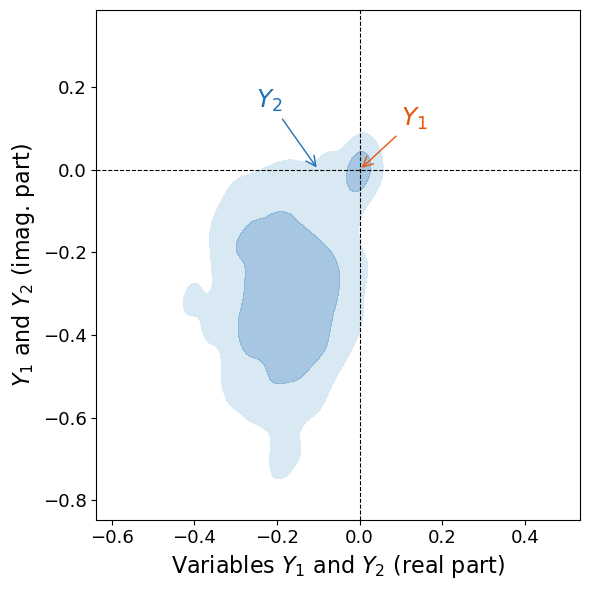

In [21]:
# Plot Y1 and Y2 together
fig, ax = plt.subplots(figsize=(6, 6))
contour = ax.contourf(X_2, Y_2, Z_2, 
                      levels=levels_2 + [Z_2.max()], 
                      colors=['#9ecae1', '#2171b5'], 
                      alpha=0.4)
contour = ax.contourf(X_1, Y_1, Z_1, 
                      levels=levels_1 + [Z_1.max()], 
                      colors=["#fdd0a2", "#e6550d"], 
                      alpha=0.7)

# Plot formatting
ax.set_xlabel("Variables $Y_1$ and $Y_2$ (real part)", fontsize=16)
ax.set_ylabel("$Y_1$ and $Y_2$ (imag. part)", fontsize=16)
# ax.set_title("Posterior Distribution of Y1 and Y2 (1σ and 2σ Contours)")
# ax.grid(True)
ax.axis('equal')

# Add dashed lines at x=0 and y=0
ax.axhline(0, color='black', linestyle='--', lw=0.8)
ax.axvline(0, color='black', linestyle='--', lw=0.8)

# Annotations and arrows
ax.annotate('$Y_1$', xy=(0.0003, 0.000055), xytext=(0.1, 0.0055 + 0.1), arrowprops=dict(facecolor='#e6550d', arrowstyle='->',color='#e6550d'), color='#e6550d', fontsize=18)
ax.annotate('$Y_2$', xy=(-0.1, 0.0), xytext=(-0.25, 0.05 + 0.1), arrowprops=dict(facecolor='#2171b5', arrowstyle='->',color='#2171b5'),color='#2171b5', fontsize=18)
plt.tick_params(axis='both', labelsize=13) 
plt.tight_layout()
plt.show()

## computing Hamiltonian

In [22]:
### calculated params 
eps = (m_c+m_d)/m_star
mu = np.array([G_const*m_star] * len(omega_c)) # as defined in paper, is this different from mu from posteriors?
gamma = m_c/m_d 
alpha = a_c/a_d 
alpha_0 = (p/(p+1))**(2/3)
Delta_pomega = pomega_c - pomega_d # ??

### use definitions to define other variables for hamiltonian
Lambda_c = Lambda_k(m_c, a_c, mu)
Lambda_d = Lambda_k(m_d, a_d, mu)

C_c = Ck(Lambda_c, e_c)
C_d = Ck(Lambda_d, e_d)

Gamma = Gamma_(p, Lambda_c,Lambda_d)
G = G_(Lambda_c, Lambda_d, C_c, C_d)

theta_res = theta_res_(p, lambda_c, lambda_d)

x_c = xk(C_c, pomega_c, theta_res)
x_d = xk(C_d, pomega_d, theta_res)

e_tilda_c = np.sqrt(2*(1 - np.sqrt(1 - e_c**2)))
e_tilda_d = np.sqrt(2*(1 - np.sqrt(1 - e_d**2)))

script_R1 = np.array([script_R1_(a, p_val) for a, p_val in zip(alpha_0, p)])
script_R2 = np.array([script_R2_(a, p_val) for a, p_val in zip(alpha_0, p)])

R1 = R1_(gamma, mu, m_d, Lambda_c, Lambda_d, script_R1)
R2 = R2_(gamma, mu, m_d, Lambda_d, script_R2)

I1 = I1_(R1, R2, C_c, C_d, Delta_pomega)
I2 = I2_(R1, R2, C_c, C_d, Delta_pomega)

K2 = K2_(P_d, Lambda_d, p, gamma, alpha_0)

Delta_G = Delta_G_(Gamma, p, gamma, alpha_0, G)

y1 = y1_(x_c,x_d,R1,R2)
theta1 = np.angle(y1)
print(f'Y1 before: {Y1}')
# Y1 = np.sqrt(2/Lambda_c) * y1
print(f'Y1: {Y1}')

print(f'alpha: {alpha}')
print(f'alpha_0: {alpha_0}')
print(f"eps: {eps}")

print(f"Lambda_c: {Lambda_c}")
print(f"Lambda_d: {Lambda_d}")
print(f"gamma: {gamma}")
print(f"mu: {mu}")
print(f"m_d: {m_d}")
print(f"script_R1: {script_R1}")
print(f"script_R2: {script_R2}")

print(f"K2 = {K2}")
print(f"I1 = {I1}")
print(f"I2 = {I2}")
print(f"Delta_G = {Delta_G}")
print(f"eps = {eps}")
print(f"R1 = {R1}")
print(f"R2 = {R2}")
print(f"theta1: {theta1}")

Y1 before: [-0.00076282+1.4221591e-04j -0.00077168+6.1151295e-05j
 -0.00082128+1.3148879e-05j ... -0.00046673+6.0848391e-04j
  0.00071566+1.1910459e-03j  0.00033637+1.2452165e-03j]
Y1: [-0.00076282+1.4221591e-04j -0.00077168+6.1151295e-05j
 -0.00082128+1.3148879e-05j ... -0.00046673+6.0848391e-04j
  0.00071566+1.1910459e-03j  0.00033637+1.2452165e-03j]
alpha: [0.82200485 0.82200557 0.8220052  ... 0.82199675 0.8219998  0.8219767 ]
alpha_0: [0.82548181 0.82548181 0.82548181 ... 0.82548181 0.82548181 0.82548181]
eps: [2.5543730e-05 2.5617501e-05 2.5211502e-05 ... 2.7704204e-05 4.1037794e-05
 3.6732548e-05]
Lambda_c: [8.4772864e-08 8.4878742e-08 8.3995872e-08 ... 9.0966765e-08 1.2063416e-07
 1.1913494e-07]
Lambda_d: [5.2400704e-08 5.2705271e-08 5.1360058e-08 ... 5.7909368e-08 1.0134726e-07
 7.8410075e-08]
gamma: [1.7843602 1.7762638 1.8038281 ... 1.7326024 1.3128719 1.6758591]
mu: [0.00023969 0.00023969 0.00023969 ... 0.00023969 0.00023969 0.00023969]
m_d: [7.4309423e-06 7.4741365e-06 7.28

In [23]:
print(f'Median Y1: {np.median(Y1)}')
print(f'Median Re(Y1): {np.real(np.median(Y1))}')
print(f'Median Im(Y1): {np.imag(np.median(Y1))}')
Y1_median = np.median(Y1)
Re_Y1_median = np.real(np.median(Y1))
Im_Y1_median = np.imag(np.median(Y1))
print(Y1)
print(Y1_median)
dist=np.abs(Y1-Y1_median)
print(dist)
median_idx = np.argmin(dist)
print(median_idx)
# median_idx = 4815 # known stable posterior sample (low ecc)
print(median_idx)

Median Y1: (-2.5611367163946852e-05+0.00079517369158566j)
Median Re(Y1): -2.5611367163946852e-05
Median Im(Y1): 0.00079517369158566
[-0.00076282+1.4221591e-04j -0.00077168+6.1151295e-05j
 -0.00082128+1.3148879e-05j ... -0.00046673+6.0848391e-04j
  0.00071566+1.1910459e-03j  0.00033637+1.2452165e-03j]
(-2.5611367e-05+0.0007951737j)
[0.0009848  0.00104661 0.00111564 ... 0.000479   0.00084036 0.00057755]
1823
1823


In [24]:
I1_val = I1[median_idx]
I2_val = I2[median_idx]
R1_val = R1[median_idx]
R2_val = R2[median_idx]
K2_val = K2[median_idx]
Delta_G_val = Delta_G[median_idx]
eps_val = eps[median_idx]

H_grid min: -1.3800437e-13
H_grid max: -9.534871e-14


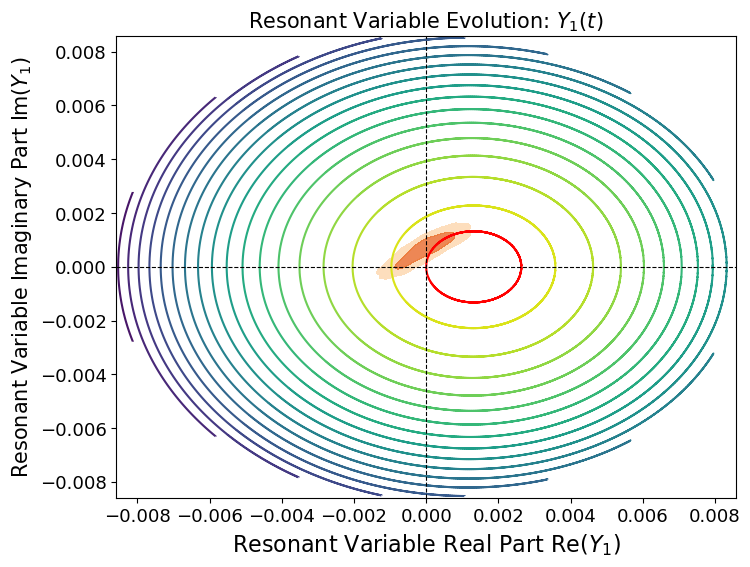

In [25]:
# Define grid for I1 and theta1
# I1_vals = np.linspace(I1_val*0.08, I1_val*4, 8000)   # I1 must be >= 0, avoid 0 to prevent sqrt(0)
I1_vals = np.linspace(I1.min()*0.002, I1.max()*6, 8000)   # I1 must be >= 0, avoid 0 to prevent sqrt(0)

# I1_vals = np.linspace(0.000000001, 0.02, 8000)
theta1_vals = np.linspace(0, 2*np.pi, 8000)

I1_grid, theta1_grid = np.meshgrid(I1_vals, theta1_vals)


# Compute Hamiltonian on the grid
H_grid = hamiltonian(K2_val, I1_grid, I2_val, Delta_G_val, eps_val, R1_val, R2_val, theta1_grid)
print("H_grid min:", H_grid.min())
print("H_grid max:", H_grid.max())


y_1 = np.sqrt(I1_grid)*np.exp(1j*theta1_grid)
Y_1_ = np.sqrt(2/np.median(Lambda_c)) * y_1
Re_Y1 = np.real(Y_1_)
Im_Y1 = np.imag(Y_1_)

# Plot Hamiltonian contours in (Re_y1, Im_y1) space
fig, ax = plt.subplots(figsize=(8, 6))

levels_circulating=[-0.08*10**(-10), -0.04*10**(-10)]
levels_resonant = [-0.01*10**(-10), 0.0, 0.01*10**(-10)]

# contours_circ = ax.contour(Re_Y1, Im_Y1, H_grid, levels=levels_circulating, colors='black',linestyles='-')
# contours_res = ax.contour(Re_Y1, Im_Y1, H_grid, levels=levels_resonant, colors='green',linestyles='-')

contours = ax.contour(Re_Y1, Im_Y1, H_grid, levels=20, cmap="viridis")

# 1. Find index closest to theta1 = π
theta1_index = np.argmin(np.abs(theta1_vals - np.pi))

# 2. Slice the Hamiltonian at that angle
H_slice = H_grid[theta1_index, :]

# 3. Find max of that slice (typical for saddle point location)
I1_saddle_index = np.argmax(H_slice)
H_saddle = H_slice[I1_saddle_index]

# Plot separatrix: contour at saddle energy
contour_sep = ax.contour(Re_Y1, Im_Y1, H_grid, levels=[H_saddle], colors='red',linestyles='-')#, linewidths=2.0)

# plt.scatter(Re_Y1_vals, Im_Y1_vals, c='blue', s=1, label=r'$Y_1(t)$ trajectory')

### add Y1 posterior distribution
contour = ax.contourf(X_1, Y_1, Z_1, 
                      levels=levels_1 + [Z_1.max()], 
                      colors=["#fdd0a2", "#e6550d"], 
                      alpha=0.7)
# Text annotation
# ax.text(0.025, 0.01, 'Posterior\ndistribution', color='#e6550d', fontsize=13, ha='center')

# plot median Y1 
# plt.scatter(np.real(np.median(Y1)), np.imag(np.median(Y1)), color='purple',label='median Y1')

# Add dashed lines at x=0 and y=0
ax.axhline(0, color='black', linestyle='--', lw=0.8)
ax.axvline(0, color='black', linestyle='--', lw=0.8)


ax.set_xlabel(r'Resonant Variable Real Part Re$(Y_1)$', fontsize=16)
ax.set_ylabel(r'Resonant Variable Imaginary Part Im$(Y_1)$', fontsize=15)
ax.set_title(r'Resonant Variable Evolution: $Y_1(t)$', fontsize=15)
# ax.grid(True)
plt.tick_params(axis='both', labelsize=13)
# plt.xlim(-0.055,0.055)
# plt.ylim(-0.045, 0.045)
# plt.legend()
plt.show()

# Check rebound

In [26]:
# load in csv
# Read the CSV
df = pd.read_csv('trajectory_rebound_draw_948.csv')

# Access the columns as needed
H_vals = df['H'].to_numpy()
Re_Y1_vals = df['Re_Y1'].to_numpy()
Im_Y1_vals = df['Im_Y1'].to_numpy()
Re_Y2_vals = df['Re_Y2'].to_numpy()
Im_Y2_vals = df['Im_Y2'].to_numpy()
I1_vals = df['I1'].to_numpy()
I2_vals = df['I2'].to_numpy()
theta1_vals = df['theta1'].to_numpy()
eb_vals = df['eb'].to_numpy()
ec_vals = df['ec'].to_numpy()
Delta_pomega_vals = df['Delta_pomega'].to_numpy()
phi1_vals = df['phi1'].to_numpy()
phi2_vals = df['phi2'].to_numpy()

H_grid min: -1.3800437e-13
H_grid max: -9.534868e-14


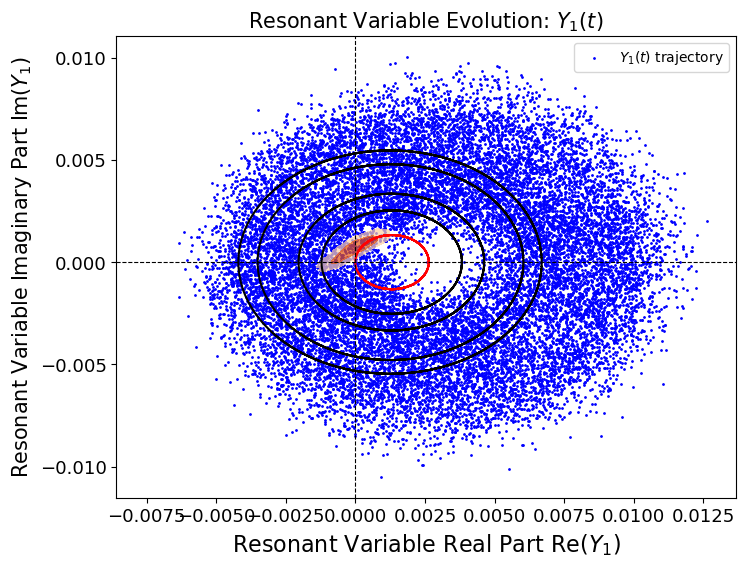

In [27]:
# Define grid for I1 and theta1
# I1_vals = np.linspace(I1_val*0.08, I1_val*4, 8000)   # I1 must be >= 0, avoid 0 to prevent sqrt(0)
I1_vals = np.linspace(I1.min()*0.002, I1.max()*6, 10000)   # I1 must be >= 0, avoid 0 to prevent sqrt(0)

# I1_vals = np.linspace(0.000000001, 0.02, 8000)
theta1_vals = np.linspace(0, 2*np.pi, 10000)

I1_grid, theta1_grid = np.meshgrid(I1_vals, theta1_vals)


# Compute Hamiltonian on the grid
H_grid = hamiltonian(K2_val, I1_grid, I2_val, Delta_G_val, eps_val, R1_val, R2_val, theta1_grid)
print("H_grid min:", H_grid.min())
print("H_grid max:", H_grid.max())

y_1 = np.sqrt(I1_grid)*np.exp(1j*theta1_grid)
Y_1_ = np.sqrt(2/np.median(Lambda_c)) * y_1
Re_Y1 = np.real(Y_1_)
Im_Y1 = np.imag(Y_1_)

# Plot Hamiltonian contours in (Re_y1, Im_y1) space
fig, ax = plt.subplots(figsize=(8, 6))

levels_circulating=[-10.8*10**(-14), -10.5*10**(-14), -10.0*10**(-14), -9.8*10**(-14), -9.5*10**(-14), -9.3*10**(-14)]
levels_resonant = [-9.23*10**(-14), -9.22*10**(-14), -9.21*10**(-14), -9.204*10**(-14)]

contours_circ = ax.contour(Re_Y1, Im_Y1, H_grid, levels=levels_circulating, colors='black',linestyles='-')
contours_res = ax.contour(Re_Y1, Im_Y1, H_grid, levels=levels_resonant, colors='green',linestyles='-')

# contours = ax.contour(Re_Y1, Im_Y1, H_grid, levels=20, cmap="viridis")

# 1. Find index closest to theta1 = π
theta1_index = np.argmin(np.abs(theta1_vals - np.pi))

# 2. Slice the Hamiltonian at that angle
H_slice = H_grid[theta1_index, :]

# 3. Find max of that slice (typical for saddle point location)
I1_saddle_index = np.argmax(H_slice)
H_saddle = H_slice[I1_saddle_index]

# Plot separatrix: contour at saddle energy
contour_sep = ax.contour(Re_Y1, Im_Y1, H_grid, levels=[H_saddle], colors='red',linestyles='-')#, linewidths=2.0)

plt.scatter(Re_Y1_vals, Im_Y1_vals, c='blue', s=1, label=r'$Y_1(t)$ trajectory')

# plt.scatter(np.real(Y1i), np.imag(Y1i), c='red', s=15, label=r'$Y_1(t)$ start point')

### add Y1 posterior distribution
contour = ax.contourf(X_1, Y_1, Z_1, 
                      levels=levels_1 + [Z_1.max()], 
                      colors=["#fdd0a2", "#e6550d"], 
                      alpha=0.7)
# Text annotation
# ax.text(0.025, 0.01, 'Posterior\ndistribution', color='#e6550d', fontsize=13, ha='center')

# plot median Y1 
# plt.scatter(np.real(np.median(Y1)), np.imag(np.median(Y1)), color='purple',label='median Y1')

# Add dashed lines at x=0 and y=0
ax.axhline(0, color='black', linestyle='--', lw=0.8)
ax.axvline(0, color='black', linestyle='--', lw=0.8)


ax.set_xlabel(r'Resonant Variable Real Part Re$(Y_1)$', fontsize=16)
ax.set_ylabel(r'Resonant Variable Imaginary Part Im$(Y_1)$', fontsize=15)
ax.set_title(r'Resonant Variable Evolution: $Y_1(t)$', fontsize=15)
# ax.grid(True)
plt.tick_params(axis='both', labelsize=13)
# plt.xlim(-0.0065,0.0075)
# plt.ylim(-0.0065, 0.0065)
plt.legend()
plt.show()

-9.607298e-14


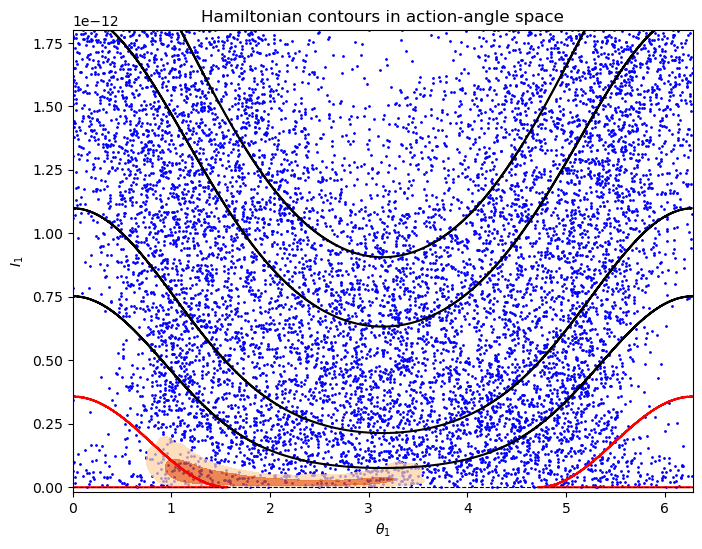

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))

plt.contour(theta1_grid, I1_grid, H_grid, levels=[H_saddle], colors='red',linestyles='-')#, linewidths=2.0)
print(H_saddle)
# contours = plt.contour(theta1_grid, I1_grid, H_grid, levels=50, cmap="viridis")

levels_circulating=[-10.8*10**(-14), -10.5*10**(-14), -10.0*10**(-14), -9.8*10**(-14), -9.5*10**(-14), -9.3*10**(-14)]
levels_resonant = [-9.23*10**(-14), -9.22*10**(-14), -9.21*10**(-14), -9.204*10**(-14)]
plt.contour(theta1_grid, I1_grid, H_grid, levels=levels_circulating, colors='black',linestyles='-')
plt.contour(theta1_grid, I1_grid, H_grid, levels=levels_resonant, colors='green',linestyles='-')

# Convert Y1 trajectory into (theta1, I1)
Y1_complex = Re_Y1_vals + 1j * Im_Y1_vals
theta1_traj = np.angle(Y1_complex)           # θ in [-π, π]
theta1_traj = np.mod(theta1_traj, 2*np.pi)  # wrap to [0, 2π]
I1_traj = (np.median(Lambda_c)/2) * np.abs(Y1_complex)**2

# Then scatter in theta1-I1 space
plt.scatter(theta1_traj, I1_traj, c='blue', s=1, label=r'$Y_1(t)$ trajectory')

### add Y1 posterior distribution in theta1-I1 space
im_Y1 = Y_1
re_Y1 = X_1
Y_1_complex = re_Y1 + 1j * im_Y1
theta1_back = np.angle(Y_1_complex)  # θ in [-π, π]
I1_back = (np.median(Lambda_c) / 2) * np.abs(Y_1_complex)**2

# Wrap θ into [0, 2π] for cleaner plotting
theta1_back = np.mod(theta1_back, 2 * np.pi)

plt.contourf(theta1_back, I1_back, Z_1, 
             levels=levels_1 + [Z_1.max()], 
             colors=["#fdd0a2", "#e6550d"], 
             alpha=0.7)

import matplotlib.patches as mpatches
# Custom legend patches
orange_1sigma = mpatches.Patch(color="#e6550d", alpha=0.7, label="Y1 (1σ contour)")
orange_2sigma = mpatches.Patch(color="#fdd0a2", alpha=0.7, label="Y1 (2σ contour)")
plt.axhline(0, color='black', linestyle='--', lw=0.8)

# Add legend
# plt.legend(handles=[scatter_pts, orange_1sigma, orange_2sigma], loc="upper right")
# plt.legend(handles=[orange_1sigma, orange_2sigma], loc="upper right")

plt.ylim(-0.02e-12, 1.8e-12)
# plt.legend()
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$I_1$')
plt.title('Hamiltonian contours in action-angle space')
plt.show()

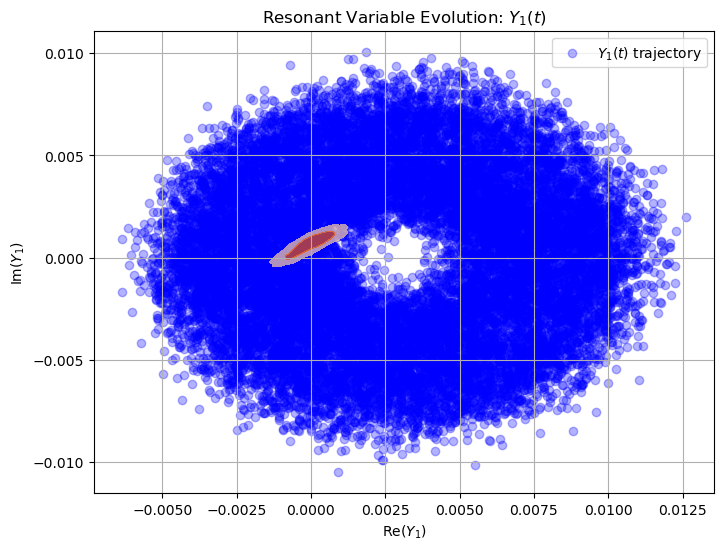

In [29]:
# Plot Y1 in Re/Im space
plt.figure(figsize=(8,6))
plt.scatter(Re_Y1_vals, Im_Y1_vals, c='blue', lw=1, alpha=0.3, label=r'$Y_1(t)$ trajectory')
contour = plt.contourf(X_1, Y_1, Z_1, 
                      levels=levels_1 + [Z_1.max()], 
                      colors=["#fdd0a2", "#e6550d"], 
                      alpha=0.7)
# plt.scatter(np.real(Y1i), np.imag(Y1i), c='green', s=15, label=r'$Y_1(t)$ start point')

plt.xlabel(r'Re$(Y_1)$')
plt.ylabel(r'Im$(Y_1)$')
plt.title(r'Resonant Variable Evolution: $Y_1(t)$')
plt.grid(True)
plt.legend()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (8000,) and (20000,)

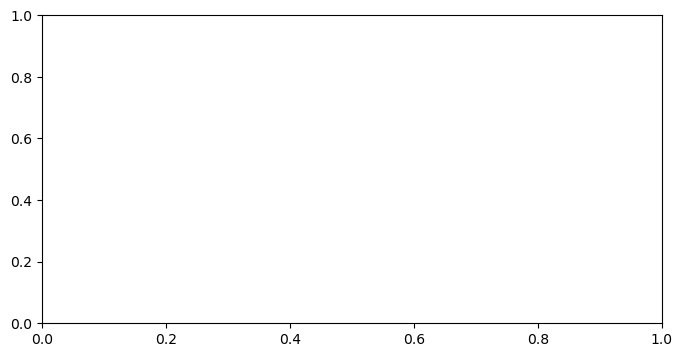

In [30]:
# Wrap angles to [-pi, pi] for easier plotting
phi1_wrapped = (phi1_vals + np.pi) % (2*np.pi) - np.pi
phi2_wrapped = (phi2_vals + np.pi) % (2*np.pi) - np.pi

phi1_wrapped = (phi1_vals) % (2*np.pi)
phi2_wrapped = (phi2_vals) % (2*np.pi)

plt.figure(figsize=(8,4))
plt.plot(times, phi1_wrapped, lw=1, label=r'$\phi_{12,1}$')
plt.plot(times, phi2_wrapped, lw=1, label=r'$\phi_{12,2}$', alpha=0.7)
plt.xlabel("Time [units]")
plt.ylabel("Critical angle [rad]")
plt.legend()
plt.title(f"Critical angles for {p[1]+1}:{p[1]} MMR")
plt.xlim(0,1000)
plt.show()

plt.figure(figsize=(8,4))
plt.scatter(times, phi1_wrapped, s=2, label=r'$\phi_{12,1}$')
plt.scatter(times, phi2_wrapped, s=2, label=r'$\phi_{12,2}$', alpha=0.7)
plt.xlabel("Time [units]")
plt.ylabel("Critical angle [rad]")
plt.legend()
plt.title(f"Critical angles for {p[1]+1}:{p[1]} MMR")
plt.xlim(0,1000)
plt.show()